In [8]:
import datetime
import io
import time
import pandas as pd
import requests
import yfinance as yf

# ---------------------------------------------------------
# 1. DATOS ESTRUCTURADOS: CO2 de la NOAA (Semanal)
# ---------------------------------------------------------
print("Descargando CO2 semanal de NOAA...")
noaa_url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_weekly_mlo.csv"
res = requests.get(noaa_url)

# El CSV de NOAA tiene comentarios iniciales marcados con '#'
noaa_lines = [
    line for line in res.text.splitlines() if not line.strip().startswith("#")
]
df_co2 = pd.read_csv(io.StringIO("\n".join(noaa_lines)))

# Formatear fecha y filtrar datos válidos (evitar valores centinela -999.99)
df_co2["date"] = pd.to_datetime(
    df_co2[["year", "month", "day"]].astype(str).agg("-".join, axis=1)
)
df_co2 = df_co2[df_co2["average"] > 0][["date", "average"]].rename(
    columns={"average": "co2_ppm"}
)

# ---------------------------------------------------------
# 2. DATOS ESTRUCTURADOS: Precio del Brent (Semanal)
# ---------------------------------------------------------
# Rango ampliado al máximo viable: BZ=F en Yahoo Finance sólo tiene
# histórico desde 2007-07-30, así que arrancamos en 2008-01-01 y
# llegamos hasta hoy (fecha dinámica) en el otro extremo.
print("Descargando precios de petróleo Brent...")
brent = yf.download(
    "BZ=F",
    start="2008-01-01",
    end=datetime.date.today().isoformat(),
    interval="1wk",
)["Close"]
df_brent = brent.reset_index()
df_brent.columns = ["date", "brent_price"]
df_brent["date"] = pd.to_datetime(df_brent["date"]).dt.tz_localize(None)

# ---------------------------------------------------------
# 3. ALINEACIÓN TEMPORAL DE SERIES NUMÉRICAS
# ---------------------------------------------------------
# Re-muestrear al final de cada semana (domingo)
df_merged = pd.merge_asof(
    df_brent.sort_values("date"),
    df_co2.sort_values("date"),
    on="date",
    direction="backward",
)

# ---------------------------------------------------------
# 4. DATOS NO ESTRUCTURADOS: Instantánea de Wikipedia
# ---------------------------------------------------------
WIKI_ENDPOINT = "https://en.wikipedia.org/w/api.php"
ARTICLE_TITLE = "Climate_change"  # O 'Cambio_climático' para español
HEADERS = {"User-Agent": "ResearchDataProject/1.0 (academic_nlp_study)"}
wiki_session = requests.Session()
wiki_session.headers.update(HEADERS)


def get_wiki_lead_at_date(title, target_date, max_retries=5):
    """Obtiene el texto de la introducción vigente en una fecha concreta.

    Reintenta con backoff cuando la API responde 429 (rate limit),
    respetando el header Retry-After en vez de descartar el resultado.
    """
    iso_timestamp = target_date.strftime("%Y-%m-%dT23:59:59Z")
    params = {
        "action": "query",
        "prop": "revisions",
        "titles": title,
        "rvlimit": 1,
        "rvstart": iso_timestamp,  # Última revisión anterior a este corte
        "rvdir": "older",
        "rvsection": 0,  # Sólo la sección 0 (la entradilla/resumen)
        "rvprop": "content|timestamp|ids",
        "format": "json",
    }
    for attempt in range(max_retries):
        try:
            resp = wiki_session.get(WIKI_ENDPOINT, params=params, timeout=15)
            if resp.status_code == 429:
                wait = int(resp.headers.get("Retry-After", 5))
                print(f"    [rate limit] esperando {wait}s antes de reintentar...")
                time.sleep(wait)
                continue
            resp.raise_for_status()
            data = resp.json()
            pages = data.get("query", {}).get("pages", {})
            page = next(iter(pages.values()))
            rev = page.get("revisions", [{}])[0]
            return {
                "rev_id": rev.get("revid"),
                "rev_timestamp": rev.get("timestamp"),
                "lead_text": rev.get("*", ""),
            }
        except requests.RequestException as e:
            print(f"    [error] intento {attempt + 1} falló para {target_date.date()}: {e}")
            time.sleep(2 * (attempt + 1))
    print(f"    [sin datos] {target_date.date()} tras {max_retries} intentos")
    return {"rev_id": None, "rev_timestamp": None, "lead_text": ""}


n_weeks = len(df_merged)
print(f"Extrayendo revisiones de Wikipedia para {n_weeks} semanas...")

wiki_records = []
n_ok = 0
n_fail = 0
start_time = time.time()
PROGRESS_EVERY = 10  # imprimir progreso cada N semanas

for idx, row in df_merged.iterrows():
    date_val = row["date"]
    rev_info = get_wiki_lead_at_date(ARTICLE_TITLE, date_val)
    wiki_records.append(rev_info)

    if rev_info["rev_id"] is not None:
        n_ok += 1
    else:
        n_fail += 1

    done = idx + 1
    if done % PROGRESS_EVERY == 0 or done == n_weeks:
        elapsed = time.time() - start_time
        rate = elapsed / done
        remaining = rate * (n_weeks - done)
        pct = 100 * done / n_weeks
        print(
            f"[{done}/{n_weeks} | {pct:5.1f}%] "
            f"semana {date_val.date()} | ok={n_ok} fail={n_fail} | "
            f"transcurrido={elapsed / 60:.1f}min restante_est={remaining / 60:.1f}min"
        )

    time.sleep(1)  # Respetar rate-limits de Wikipedia

print(f"Extracción de Wikipedia terminada: {n_ok} ok, {n_fail} fallidas.")

df_wiki = pd.DataFrame(wiki_records)
dataset_final = pd.concat(
    [df_merged.reset_index(drop=True), df_wiki], axis=1
)

# ---------------------------------------------------------
# 5. GUARDAR EL DATASET
# ---------------------------------------------------------
dataset_final.to_parquet("dataset_clima_multimodal.parquet", index=False)
print("¡Completado! Registros guardados:", len(dataset_final))

Descargando CO2 semanal de NOAA...
Descargando precios de petróleo Brent...


[*********************100%***********************]  1 of 1 completed


Extrayendo revisiones de Wikipedia para 977 semanas...
[10/977 |   1.0%] semana 2008-03-04 | ok=10 fail=0 | transcurrido=0.2min restante_est=18.5min
[20/977 |   2.0%] semana 2008-05-13 | ok=20 fail=0 | transcurrido=0.4min restante_est=18.9min
[30/977 |   3.1%] semana 2008-07-22 | ok=30 fail=0 | transcurrido=0.6min restante_est=19.1min
[40/977 |   4.1%] semana 2008-09-30 | ok=40 fail=0 | transcurrido=0.8min restante_est=19.0min
[50/977 |   5.1%] semana 2008-12-09 | ok=50 fail=0 | transcurrido=1.0min restante_est=18.9min
[60/977 |   6.1%] semana 2009-02-17 | ok=60 fail=0 | transcurrido=1.2min restante_est=18.8min
[70/977 |   7.2%] semana 2009-05-05 | ok=70 fail=0 | transcurrido=1.4min restante_est=18.7min
[80/977 |   8.2%] semana 2009-07-14 | ok=80 fail=0 | transcurrido=1.7min restante_est=18.5min
[90/977 |   9.2%] semana 2009-09-22 | ok=90 fail=0 | transcurrido=1.9min restante_est=18.4min
[100/977 |  10.2%] semana 2009-12-01 | ok=100 fail=0 | transcurrido=2.1min restante_est=18.2min
[11

In [9]:
import pandas as pd

df = pd.read_parquet("dataset_clima_multimodal.parquet")

print("Shape:", df.shape)
print("\nColumnas y tipos:")
print(df.dtypes)

print("\nNulos por columna:")
print(df.isna().sum())

print("\nPrimeras filas:")
display(df.head())

print("\nEjemplo de lead_text (fila 0):")
print(df.loc[0, "lead_text"][:500], "...")

df.describe(include="all").T

Shape: (977, 6)

Columnas y tipos:
date             datetime64[ns]
brent_price             float64
co2_ppm                 float64
rev_id                    int64
rev_timestamp            object
lead_text                object
dtype: object

Nulos por columna:
date             0
brent_price      0
co2_ppm          0
rev_id           0
rev_timestamp    0
lead_text        0
dtype: int64

Primeras filas:


,date,brent_price,co2_ppm,rev_id,rev_timestamp,lead_text
0,2008-01-01,94.389999,385.02,181256649,2007-12-31T20:34:41Z,{{protected}}{{featured article}}\n{{FixHTML|b...
1,2008-01-08,92.919998,384.67,182998980,2008-01-08T18:48:52Z,{{pp-semi-protected|small=yes}}{{featured arti...
2,2008-01-15,87.699997,386.05,184549115,2008-01-15T19:54:07Z,{{pp-semi-protected|small=yes}}{{featured arti...
3,2008-01-22,91.379997,386.25,186170401,2008-01-22T19:15:56Z,{{pp-semi-protected|small=yes}}{{featured arti...
4,2008-01-29,90.400002,387.02,187783856,2008-01-29T21:54:11Z,{{pp-semi-protected|small=yes}}{{featured arti...



Ejemplo de lead_text (fila 0):
{{protected}}{{featured article}}
{{FixHTML|beg}}
[[Image:Instrumental Temperature Record.png|thumb|280px|right|Global mean surface temperature anomaly 1850 to 2006 relative to 1961–1990]]
{{FixHTML|mid}}
[[Image:Global Warming Map.jpg|thumb|280px|right|Mean surface temperature anomalies during the period 1995 to 2004 with respect to the average temperatures from 1940 to 1980]]
{{FixHTML|end}}

<!-- Please keep the intro as a simple declarative sentence. Details should be placed later.-->
'''Glo ...


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,977,NaN,NaN,NaN,2017-05-15 12:18:25.424769792,2008-01-01 00:00:00,2012-09-11 00:00:00,2017-05-16 00:00:00,2022-01-18 00:00:00,2026-09-22 00:00:00,NaN
brent_price,977.0,NaN,NaN,NaN,78.488383,19.99,60.939999,76.029999,99.940002,143.919998,23.985782
co2_ppm,977.0,NaN,NaN,NaN,406.496469,382.97,394.45,406.52,417.76,432.44,13.431426
rev_id,977.0,NaN,NaN,NaN,785939610.691914,181256649.0,511660458.0,780172059.0,1066514474.0,1376019004.0,333341510.289297
rev_timestamp,977,923,2018-01-19T23:24:25Z,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_text,977,580,{{Short description|Human-caused changes to cl...,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.lead_text.str.len().value_counts().sort_index(ascending=False)

lead_text
27557    1
27309    2
26976    1
26973    1
24124    7
        ..
4265     1
4242     1
4212     1
4076     1
4066     3
Name: count, Length: 547, dtype: int64

In [11]:
n_total = len(df)
n_unicos = df["lead_text"].nunique(dropna=False)
n_duplicados = n_total - n_unicos

print("Total de filas:", n_total)
print("Valores únicos en lead_text:", n_unicos)
print("Filas duplicadas (texto idéntico a otra):", n_duplicados)

Total de filas: 977
Valores únicos en lead_text: 580
Filas duplicadas (texto idéntico a otra): 397


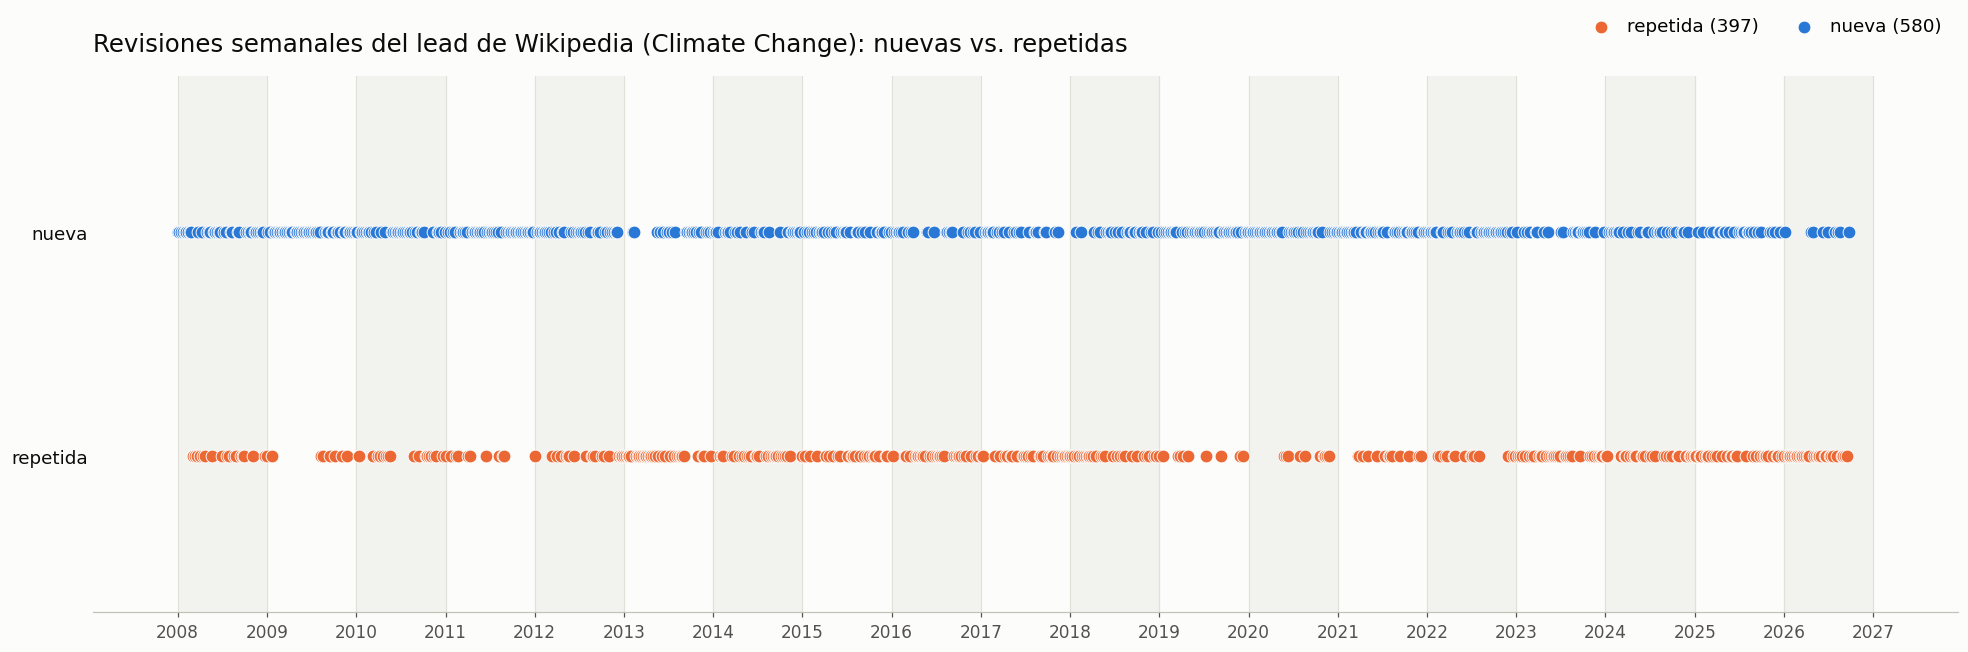

Entradas nuevas: 580
Entradas repetidas: 397

Intervalos más largos sin cambios en el lead_text (top 10):
  2026-01-06 -> 2026-04-14 |   98 días (15 semanas sin cambio)
  2013-02-12 -> 2013-05-07 |   84 días (13 semanas sin cambio)
  2017-11-14 -> 2018-01-16 |   63 días (10 semanas sin cambio)
  2012-12-04 -> 2013-01-29 |   56 días (9 semanas sin cambio)
  2023-05-09 -> 2023-06-27 |   49 días (8 semanas sin cambio)
  2018-02-13 -> 2018-04-03 |   49 días (8 semanas sin cambio)
  2016-03-29 -> 2016-05-17 |   49 días (8 semanas sin cambio)
  2016-06-21 -> 2016-08-02 |   42 días (7 semanas sin cambio)
  2026-04-28 -> 2026-06-02 |   35 días (6 semanas sin cambio)
  2014-08-19 -> 2014-09-23 |   35 días (6 semanas sin cambio)


In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_sorted = df.sort_values("date").reset_index(drop=True)

# 'nueva' si el texto difiere del de la semana anterior; 'repetida' si es igual
is_new = df_sorted["lead_text"].ne(df_sorted["lead_text"].shift(1))
is_new.iloc[0] = True  # la primera entrada siempre cuenta como nueva
df_sorted["entry_type"] = is_new.map({True: "nueva", False: "repetida"})

# --- Gráfico: timeline de entradas nuevas vs repetidas ---
COLOR_NEW = "#2a78d6"       # slot categórico 1 (azul)
COLOR_REPEATED = "#eb6834"  # slot categórico 2 (naranja)
SURFACE = "#fcfcfb"
GRID = "#e1e0d9"
INK = "#0b0b0b"
INK_MUTED = "#52514e"

fig, ax = plt.subplots(figsize=(18, 6), dpi=110)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

# bandas alternadas por año para orientar la lectura sobre ~18 años de datos
years = sorted(df_sorted["date"].dt.year.unique())
for y in years:
    if y % 2 == 0:
        ax.axvspan(
            pd.Timestamp(f"{y}-01-01"), pd.Timestamp(f"{y + 1}-01-01"),
            color=GRID, alpha=0.35, zorder=0, lw=0,
        )

# dos carriles: repetida abajo, nueva arriba, para que no se solapen
Y_REPEATED, Y_NEW = 0, 1
for label, color, y in [("repetida", COLOR_REPEATED, Y_REPEATED), ("nueva", COLOR_NEW, Y_NEW)]:
    mask = df_sorted["entry_type"] == label
    ax.scatter(
        df_sorted.loc[mask, "date"],
        [y] * mask.sum(),
        s=70,
        color=color,
        label=f"{label} ({mask.sum()})",
        zorder=3,
        edgecolors=SURFACE,
        linewidths=0.6,
    )

ax.set_yticks([Y_REPEATED, Y_NEW])
ax.set_yticklabels(["repetida", "nueva"], fontsize=12, color=INK)
ax.set_ylim(-0.7, 1.7)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", colors=INK_MUTED, labelsize=11, rotation=0)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", color=GRID, linewidth=0.8, zorder=0)

ax.set_title(
    "Revisiones semanales del lead de Wikipedia (Climate Change): nuevas vs. repetidas",
    fontsize=16, color=INK, pad=16, loc="left",
)
ax.legend(
    loc="upper right", bbox_to_anchor=(1, 1.14), ncol=2, frameon=False,
    fontsize=12, handletextpad=0.4, columnspacing=1.5,
)

plt.tight_layout()
plt.show()

print(f"Entradas nuevas: {(df_sorted['entry_type'] == 'nueva').sum()}")
print(f"Entradas repetidas: {(df_sorted['entry_type'] == 'repetida').sum()}")

# --- Intervalos más largos sin cambios ---
change_id = is_new.cumsum()
streaks = (
    df_sorted.groupby(change_id)
    .agg(start=("date", "first"), end=("date", "last"), n_semanas=("date", "size"))
)
streaks["duracion_dias"] = (streaks["end"] - streaks["start"]).dt.days
streaks = streaks.sort_values("duracion_dias", ascending=False)

print("\nIntervalos más largos sin cambios en el lead_text (top 10):")
for _, row in streaks.head(10).iterrows():
    print(
        f"  {row['start'].date()} -> {row['end'].date()} "
        f"| {row['duracion_dias']:>4} días ({row['n_semanas']} semanas sin cambio)"
    )
